<a href="https://colab.research.google.com/github/RaJ-0002/DataScience/blob/master/final_project_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !pip install schedule

In [ ]:
# pip install pandas requests tqdm

In [ ]:
import pandas as pd
import requests
import io
import numpy as np
import os
from tqdm import tqdm
from datetime import datetime, timedelta
import requests, io, zipfile, datetime, time
import schedule
# import time
import yfinance as yf

In [ ]:
import yfinance as yf
import pandas as pd

# -----------------------------
# Download Historical Data
# -----------------------------
nasdaq = yf.download("^IXIC", start="2024-01-01", end="2025-01-01")
gold = yf.download("GC=F", start="2024-01-01", end="2025-01-01")
btc = yf.download("BTC-USD", start="2024-01-01", end="2025-01-01")

# -----------------------------
# Combine 'Close' Prices
# -----------------------------
data = pd.concat([nasdaq['Close'], gold['Close'], btc['Close']], axis=1)
data.columns = ['NASDAQ', 'Gold', 'Bitcoin']

# Reset the index so 'Date' becomes a column instead of index
data.reset_index(inplace=True)

# -----------------------------
# Save to CSV File
# -----------------------------
data.to_csv("Market_Prices_2024_2025.csv", index=False)

print("✅ File saved successfully as 'Market_Prices_2024_2025.csv'")
print(data.head())


/tmp/ipython-input-2371291584.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nasdaq = yf.download("^IXIC", start="2024-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2371291584.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold = yf.download("GC=F", start="2024-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2371291584.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start="2024-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed

✅ File saved successfully as 'Market_Prices_2024_2025.csv'
        Date        NASDAQ         Gold       Bitcoin
0 2024-01-01           NaN          NaN  44167.332031
1 2024-01-02  14765.940430  2064.399902  44957.968750
2 2024-01-03  14592.209961  2034.199951  42848.175781
3 2024-01-04  14510.299805  2042.300049  44179.921875
4 2024-01-05  14524.070312  2042.400024  44162.691406


In [ ]:
# import yfinance as yf
# data = yf.download("^IXIC", start="2015-01-01", end="2025-10-11")
# data.to_csv("NASDAQ_Composite.csv")


**##Events Dataset**

In [ ]:
# import pandas as pd
# import numpy as np
# import requests, io, zipfile, time
# from tqdm import tqdm

# # Full Event Table columns (V2.0)
# event_columns = [
#     "GlobalEventID","Day","MonthYear","Year","FractionDate","DATEADDED",
#     "Actor1Code","Actor1Name","Actor1CountryCode","Actor1KnownGroupCode",
#     "Actor1EthnicCode","Actor1Religion1Code","Actor1Religion2Code",
#     "Actor1Type1Code","Actor1Type2Code","Actor1Type3Code",
#     "Actor2Code","Actor2Name","Actor2CountryCode","Actor2KnownGroupCode",
#     "Actor2EthnicCode","Actor2Religion1Code","Actor2Religion2Code",
#     "Actor2Type1Code","Actor2Type2Code","Actor2Type3Code",
#     "IsRootEvent","EventCode","EventBaseCode","EventRootCode","QuadClass",
#     "GoldsteinScale","NumMentions","NumSources","NumArticles","AvgTone",
#     "Actor1Geo_Type","Actor1Geo_Fullname","Actor1Geo_CountryCode",
#     "Actor1Geo_ADM1Code","Actor1Geo_ADM2Code","Actor1Geo_Lat",
#     "Actor1Geo_Long","Actor1Geo_FeatureID",
#     "Actor2Geo_Type","Actor2Geo_Fullname","Actor2Geo_CountryCode",
#     "Actor2Geo_ADM1Code","Actor2Geo_ADM2Code","Actor2Geo_Lat",
#     "Actor2Geo_Long","Actor2Geo_FeatureID",
#     "ActionGeo_Type","ActionGeo_Fullname","ActionGeo_CountryCode",
#     "ActionGeo_ADM1Code","ActionGeo_ADM2Code","ActionGeo_Lat",
#     "ActionGeo_Long","ActionGeo_FeatureID",
#     "SOURCEURL"
# ]

# def fetch_gdelt_full(start_year=2023, end_year=2025, frequency='M'):
#     all_data = []
#     base_urls = {"2.0": "http://data.gdeltproject.org/events/"}

#     # Generate 1 date per month
#     all_dates = pd.date_range(f"{start_year}-01-01", f"{end_year}-12-31", freq=frequency)

#     for date in tqdm(all_dates):
#         yyyymmdd = date.strftime("%Y%m%d")
#         url = f"{base_urls['2.0']}{yyyymmdd}.export.CSV.zip"

#         try:
#             response = requests.get(url, timeout=25)
#             if response.status_code == 200:
#                 z = zipfile.ZipFile(io.BytesIO(response.content))
#                 filename = z.namelist()[0]
#                 with z.open(filename) as f:
#                     df = pd.read_csv(f, sep='\t', header=None, names=event_columns, low_memory=False)
#                     df['Day'] = pd.to_datetime(df['Day'], format='%Y%m%d')
#                     all_data.append(df)
#             else:
#                 print(f"Skipped {yyyymmdd} - file not found.")
#         except Exception as e:
#             print(f"Error fetching {yyyymmdd}: {e}")
#             continue

#         time.sleep(0.2)  # prevent overload

#     if len(all_data) == 0:
#         raise ValueError("No data downloaded. Check connection or URLs.")
#     return pd.concat(all_data, ignore_index=True)

# # Example usage
# df = fetch_gdelt_full(2023, 2025, frequency='MS')
# print("Shape:", df.shape)
# print(df.head())


In [ ]:
import pandas as pd
import numpy as np
import requests, io, zipfile, datetime, time
from tqdm import tqdm

def fetch_gdelt_sampled(start_year=2024, end_year=2025, frequency='M'):
    all_data = []
    base_urls = {
        "1.0": "http://data.gdeltproject.org/events/",
        "2.0": "http://data.gdeltproject.org/events/"
    }

    # Generate 1 day per month
    all_dates = pd.date_range(f"{start_year}-01-01", f"{end_year}-12-31", freq=frequency)

    for date in tqdm(all_dates):
        yyyymmdd = date.strftime("%Y%m%d")

        # Determine version
        if date < pd.Timestamp("2015-02-19"):
            version = "1.0"
            url = f"{base_urls[version]}{yyyymmdd}.export.CSV.zip"
        else:
            version = "2.0"
            url = f"{base_urls[version]}{yyyymmdd}.export.CSV.zip"

        try:
            response = requests.get(url, timeout=25)
            if response.status_code == 200:
                z = zipfile.ZipFile(io.BytesIO(response.content))
                filename = z.namelist()[0]
                with z.open(filename) as f:
                    df = pd.read_csv(
                        f, sep='\t', header=None, low_memory=False,
                        usecols=[0, 1, 26, 28, 30, 31, 32, 33, 34, 53],
                        names=['GlobalEventID','Day','EventRootCode','QuadClass',
                               'GoldsteinScale','NumMentions','NumSources',
                               'NumArticles','AvgTone','SOURCEURL']
                    )
                    df['Day'] = pd.to_datetime(df['Day'], format='%Y%m%d')
                    df['Version'] = version
                    all_data.append(df)
            else:
                print(f"Skipped {yyyymmdd} - file not found.")
        except Exception as e:
            print(f"Error fetching {yyyymmdd}: {e}")
            continue

        time.sleep(0.2)  # prevent overload

    if len(all_data) == 0:
        raise ValueError("No data downloaded. Check connection or URLs.")
    return pd.concat(all_data, ignore_index=True)


In [ ]:
df = fetch_gdelt_sampled(2024, 2025, frequency='MS')  # Monthly Start Dates

print("Shape:", df.shape)
print(df.head())

 79%|███████▉  | 19/24 [00:36<00:07,  1.41s/it]

Skipped 20250701 - file not found.


 96%|█████████▌| 23/24 [00:43<00:01,  1.40s/it]

Skipped 20251101 - file not found.


100%|██████████| 24/24 [00:43<00:00,  1.08s/it]

Skipped 20251201 - file not found.


100%|██████████| 24/24 [00:43<00:00,  1.82s/it]


Shape: (2430424, 11)
   GlobalEventID        Day  EventRootCode  QuadClass  GoldsteinScale  \
0     1149157552 2023-01-01             60          6             6.0   
1     1149157553 2023-01-01             50          5             3.5   
2     1149157554 2023-01-01             51          5             3.4   
3     1149157555 2023-01-01             51          5             3.4   
4     1149157556 2023-01-01             51          5             3.4   

   NumMentions  NumSources  NumArticles   AvgTone  SOURCEURL Version  
0           10           1           10 -1.029748  39.828175     2.0  
1            2           1            2 -0.800000  39.928900     2.0  
2            2           1            2  0.000000  46.000000     2.0  
3            6           1            6  0.000000  35.730200     2.0  
4            2           1            2  0.000000  46.000000     2.0  


In [ ]:
import pandas as pd

# Example: your DataFrame is called df
# Export to CSV
df.to_csv('events.csv', index=False)  # index=False avoids writing row numbers


In [ ]:
# Calculate the percentage of null values
null_percentage = df.isnull().sum() / len(df) * 100

# Display the percentage of null values
print("Percentage of null values per column:")
print(null_percentage)

Percentage of null values per column:
GlobalEventID     0.000000
Day               0.000000
EventRootCode     0.000000
QuadClass         0.000000
GoldsteinScale    0.000329
NumMentions       0.000000
NumSources        0.000000
NumArticles       0.000000
AvgTone           0.000000
SOURCEURL         2.772685
Version           0.000000
dtype: float64


In [ ]:
import pandas as pd

# Read the two CSV files into DataFrames
market_prices_df = pd.read_csv("Market_Prices_2024_2025.csv")
events_df = pd.read_csv("events.csv")

# Convert the 'Date' column in market_prices_df to datetime objects
market_prices_df['Date'] = pd.to_datetime(market_prices_df['Date'])

# Convert the 'Day' column in events_df to datetime objects and rename it to 'Date'
events_df['Day'] = pd.to_datetime(events_df['Day'])
events_df = events_df.rename(columns={'Day': 'Date'})

# Merge the two DataFrames on the 'Date' column
merged_df = pd.merge(market_prices_df, events_df, on='Date', how='inner')

# Display the head of the merged DataFrame
display(merged_df.head())

,Date,NASDAQ,Gold,Bitcoin,GlobalEventID,EventRootCode,QuadClass,GoldsteinScale,NumMentions,NumSources,NumArticles,AvgTone,SOURCEURL,Version
0,2024-01-01,NaN,NaN,44167.332031,1149157574,42,4,1.9,20,2,20,-1.093286,NaN,2.0
1,2024-01-01,NaN,NaN,44167.332031,1149157575,42,4,1.9,10,1,10,1.789401,-10.0000,2.0
2,2024-01-01,NaN,NaN,44167.332031,1149157576,20,2,3.0,18,2,18,-18.280855,-35.2833,2.0
3,2024-01-01,NaN,NaN,44167.332031,1149157577,36,3,4.0,200,11,120,1.274040,-33.8833,2.0
4,2024-01-01,NaN,NaN,44167.332031,1149157578,43,4,2.8,1335,62,1315,2.516222,-33.8833,2.0


In [ ]:
# Calculate the percentage of null values
null_percentage = merged_df.isnull().sum() / len(merged_df) * 100

# Display the percentage of null values
print("Percentage of null values per column:")
print(null_percentage)

Percentage of null values per column:
Date               0.000000
NASDAQ            21.593864
Gold              21.593864
Bitcoin            0.000000
GlobalEventID      0.000000
EventRootCode      0.000000
QuadClass          0.000000
GoldsteinScale     0.000418
NumMentions        0.000000
NumSources         0.000000
NumArticles        0.000000
AvgTone            0.000000
SOURCEURL          2.793753
Version            0.000000
dtype: float64


In [ ]:
# Identify numerical columns
numerical_cols = merged_df.select_dtypes(include=np.number).columns

# Fill null values in numerical columns using linear interpolation
for col in numerical_cols:
    merged_df[col].interpolate(method='linear', axis=0, inplace=True)

# Display the percentage of null values after interpolation
print("Percentage of null values per column after interpolation:")
print(merged_df.isnull().sum() / len(merged_df) * 100)

/tmp/ipython-input-2771150216.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_df[col].interpolate(method='linear', axis=0, inplace=True)


Percentage of null values per column after interpolation:
Date              0.00000
NASDAQ            4.60988
Gold              4.60988
Bitcoin           0.00000
GlobalEventID     0.00000
EventRootCode     0.00000
QuadClass         0.00000
GoldsteinScale    0.00000
NumMentions       0.00000
NumSources        0.00000
NumArticles       0.00000
AvgTone           0.00000
SOURCEURL         0.00007
Version           0.00000
dtype: float64


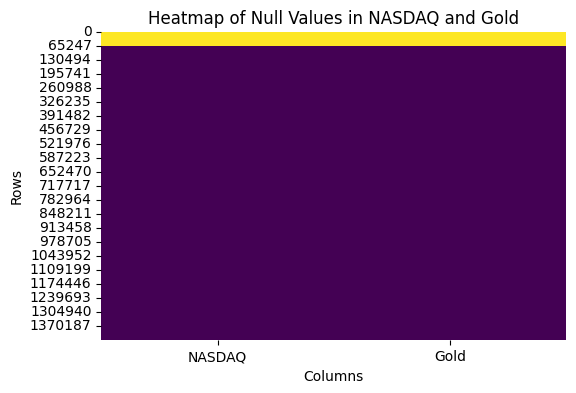

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the 'NASDAQ' and 'Gold' columns and check for null values
null_data = merged_df[['NASDAQ', 'Gold']].isnull()

# Create a heatmap of null values
plt.figure(figsize=(6, 4))
sns.heatmap(null_data, cmap='viridis', cbar=False)
plt.title('Heatmap of Null Values in NASDAQ and Gold')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

In [ ]:
merged_df.drop("Version", axis=1, inplace=True)

In [ ]:
# Drop rows with any null values
merged_df.dropna(inplace=True)

# Display the shape of the DataFrame after dropping null values
print("Shape of the DataFrame after dropping null values:", merged_df.shape)

Shape of the DataFrame after dropping null values: (1369246, 13)


In [ ]:
print(merged_df.isnull().sum() / len(merged_df) * 100)

Date              0.0
NASDAQ            0.0
Gold              0.0
Bitcoin           0.0
GlobalEventID     0.0
EventRootCode     0.0
QuadClass         0.0
GoldsteinScale    0.0
NumMentions       0.0
NumSources        0.0
NumArticles       0.0
AvgTone           0.0
SOURCEURL         0.0
dtype: float64


In [ ]:
merged_df.shape

(1369246, 14)

In [ ]:
# Calculate the correlation matrix for numerical columns
correlation_matrix = merged_df.corr(numeric_only=True)

# Display the correlation matrix
display(correlation_matrix)

,NASDAQ,Gold,Bitcoin,GlobalEventID,EventRootCode,QuadClass,GoldsteinScale,NumMentions,NumSources,NumArticles,AvgTone,SOURCEURL
NASDAQ,1.000000,0.849902,0.684977,0.879431,-0.004977,-0.006758,0.002673,-0.005781,-0.004161,-0.005889,0.020741,-0.023520
Gold,0.849902,1.000000,0.547965,0.949102,-0.003790,-0.000518,-0.005739,-0.000598,0.003341,-0.000715,0.009106,-0.013556
Bitcoin,0.684977,0.547965,1.000000,0.594569,-0.003014,-0.006915,0.004970,-0.003280,-0.000695,-0.003156,0.014513,-0.014983
GlobalEventID,0.879431,0.949102,0.594569,1.000000,-0.003769,-0.000614,-0.003378,-0.002087,0.001475,-0.002198,0.010555,-0.015336
EventRootCode,-0.004977,-0.003790,-0.003014,-0.003769,1.000000,0.418927,-0.260975,0.002090,0.007219,0.002447,-0.170999,0.007534
QuadClass,-0.006758,-0.000518,-0.006915,-0.000614,0.418927,1.000000,-0.759074,0.008574,0.017600,0.008645,-0.328614,0.027908
GoldsteinScale,0.002673,-0.005739,0.004970,-0.003378,-0.260975,-0.759074,1.000000,-0.012528,-0.024241,-0.012661,0.352903,-0.019797
NumMentions,-0.005781,-0.000598,-0.003280,-0.002087,0.002090,0.008574,-0.012528,1.000000,0.799834,0.990555,-0.030940,0.000541
NumSources,-0.004161,0.003341,-0.000695,0.001475,0.007219,0.017600,-0.024241,0.799834,1.000000,0.810757,-0.056716,0.020137
NumArticles,-0.005889,-0.000715,-0.003156,-0.002198,0.002447,0.008645,-0.012661,0.990555,0.810757,1.000000,-0.032309,0.002101


In [ ]:
print(merged_df['SOURCEURL'].dtype)

float64
